In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)
sns.set_theme(style="whitegrid")

In [2]:
# =========================
# 1. Chargement des données
# =========================

insurance_claims = pd.read_csv("insurance_claims.csv")

train_auto = pd.read_csv("train_auto.csv")

test_auto = pd.read_csv("test_auto.csv")

fraud_oracle = pd.read_csv("fraud_oracle.csv")

In [3]:
datasets = {
    "Insurance Claims": insurance_claims,
    "Auto Insurance Train": train_auto,
    "Auto Insurance Test": test_auto,
    "Fraud Oracle": fraud_oracle
}

for name, df in datasets.items():
    print(f"{name}: {df.shape}")

Insurance Claims: (1000, 40)
Auto Insurance Train: (8161, 26)
Auto Insurance Test: (2141, 26)
Fraud Oracle: (15420, 33)


In [4]:
for name, df in datasets.items():
    print(f"\n===== {name} =====")
    display(df.head())


===== Insurance Claims =====


,months_as_customer,age,policy_number,policy_bind_date,policy_state,policy_csl,policy_deductable,policy_annual_premium,umbrella_limit,insured_zip,insured_sex,insured_education_level,insured_occupation,insured_hobbies,insured_relationship,capital-gains,capital-loss,incident_date,incident_type,collision_type,incident_severity,authorities_contacted,incident_state,incident_city,incident_location,incident_hour_of_the_day,number_of_vehicles_involved,property_damage,bodily_injuries,witnesses,police_report_available,total_claim_amount,injury_claim,property_claim,vehicle_claim,auto_make,auto_model,auto_year,fraud_reported,_c39
0,328,48,521585,2014-10-17,OH,250/500,1000,1406.91,0,466132,MALE,MD,craft-repair,sleeping,husband,53300,0,2015-01-25,Single Vehicle Collision,Side Collision,Major Damage,Police,SC,Columbus,9935 4th Drive,5,1,YES,1,2,YES,71610,6510,13020,52080,Saab,92x,2004,Y,NaN
1,228,42,342868,2006-06-27,IN,250/500,2000,1197.22,5000000,468176,MALE,MD,machine-op-inspct,reading,other-relative,0,0,2015-01-21,Vehicle Theft,?,Minor Damage,Police,VA,Riverwood,6608 MLK Hwy,8,1,?,0,0,?,5070,780,780,3510,Mercedes,E400,2007,Y,NaN
2,134,29,687698,2000-09-06,OH,100/300,2000,1413.14,5000000,430632,FEMALE,PhD,sales,board-games,own-child,35100,0,2015-02-22,Multi-vehicle Collision,Rear Collision,Minor Damage,Police,NY,Columbus,7121 Francis Lane,7,3,NO,2,3,NO,34650,7700,3850,23100,Dodge,RAM,2007,N,NaN
3,256,41,227811,1990-05-25,IL,250/500,2000,1415.74,6000000,608117,FEMALE,PhD,armed-forces,board-games,unmarried,48900,-62400,2015-01-10,Single Vehicle Collision,Front Collision,Major Damage,Police,OH,Arlington,6956 Maple Drive,5,1,?,1,2,NO,63400,6340,6340,50720,Chevrolet,Tahoe,2014,Y,NaN
4,228,44,367455,2014-06-06,IL,500/1000,1000,1583.91,6000000,610706,MALE,Associate,sales,board-games,unmarried,66000,-46000,2015-02-17,Vehicle Theft,?,Minor Damage,NaN,NY,Arlington,3041 3rd Ave,20,1,NO,0,1,NO,6500,1300,650,4550,Accura,RSX,2009,N,NaN



===== Auto Insurance Train =====


,INDEX,TARGET_FLAG,TARGET_AMT,KIDSDRIV,AGE,HOMEKIDS,YOJ,INCOME,PARENT1,HOME_VAL,MSTATUS,SEX,EDUCATION,JOB,TRAVTIME,CAR_USE,BLUEBOOK,TIF,CAR_TYPE,RED_CAR,OLDCLAIM,CLM_FREQ,REVOKED,MVR_PTS,CAR_AGE,URBANICITY
0,1,0,0.0,0,60.0,0,11.0,"$67,349",No,$0,z_No,M,PhD,Professional,14,Private,"$14,230",11,Minivan,yes,"$4,461",2,No,3,18.0,Highly Urban/ Urban
1,2,0,0.0,0,43.0,0,11.0,"$91,449",No,"$257,252",z_No,M,z_High School,z_Blue Collar,22,Commercial,"$14,940",1,Minivan,yes,$0,0,No,0,1.0,Highly Urban/ Urban
2,4,0,0.0,0,35.0,1,10.0,"$16,039",No,"$124,191",Yes,z_F,z_High School,Clerical,5,Private,"$4,010",4,z_SUV,no,"$38,690",2,No,3,10.0,Highly Urban/ Urban
3,5,0,0.0,0,51.0,0,14.0,NaN,No,"$306,251",Yes,M,<High School,z_Blue Collar,32,Private,"$15,440",7,Minivan,yes,$0,0,No,0,6.0,Highly Urban/ Urban
4,6,0,0.0,0,50.0,0,NaN,"$114,986",No,"$243,925",Yes,z_F,PhD,Doctor,36,Private,"$18,000",1,z_SUV,no,"$19,217",2,Yes,3,17.0,Highly Urban/ Urban



===== Auto Insurance Test =====


,INDEX,TARGET_FLAG,TARGET_AMT,KIDSDRIV,AGE,HOMEKIDS,YOJ,INCOME,PARENT1,HOME_VAL,MSTATUS,SEX,EDUCATION,JOB,TRAVTIME,CAR_USE,BLUEBOOK,TIF,CAR_TYPE,RED_CAR,OLDCLAIM,CLM_FREQ,REVOKED,MVR_PTS,CAR_AGE,URBANICITY
0,3,NaN,NaN,0,48.0,0,11.0,"$52,881",No,$0,z_No,M,Bachelors,Manager,26,Private,"$21,970",1,Van,yes,$0,0,No,2,10.0,Highly Urban/ Urban
1,9,NaN,NaN,1,40.0,1,11.0,"$50,815",Yes,$0,z_No,M,z_High School,Manager,21,Private,"$18,930",6,Minivan,no,"$3,295",1,No,2,1.0,Highly Urban/ Urban
2,10,NaN,NaN,0,44.0,2,12.0,"$43,486",Yes,$0,z_No,z_F,z_High School,z_Blue Collar,30,Commercial,"$5,900",10,z_SUV,no,$0,0,No,0,10.0,z_Highly Rural/ Rural
3,18,NaN,NaN,0,35.0,2,NaN,"$21,204",Yes,$0,z_No,M,z_High School,Clerical,74,Private,"$9,230",6,Pickup,no,$0,0,Yes,0,4.0,z_Highly Rural/ Rural
4,21,NaN,NaN,0,59.0,0,12.0,"$87,460",No,$0,z_No,M,z_High School,Manager,45,Private,"$15,420",1,Minivan,yes,"$44,857",2,No,4,1.0,Highly Urban/ Urban



===== Fraud Oracle =====


,Month,WeekOfMonth,DayOfWeek,Make,AccidentArea,DayOfWeekClaimed,MonthClaimed,WeekOfMonthClaimed,Sex,MaritalStatus,Age,Fault,PolicyType,VehicleCategory,VehiclePrice,FraudFound_P,PolicyNumber,RepNumber,Deductible,DriverRating,Days_Policy_Accident,Days_Policy_Claim,PastNumberOfClaims,AgeOfVehicle,AgeOfPolicyHolder,PoliceReportFiled,WitnessPresent,AgentType,NumberOfSuppliments,AddressChange_Claim,NumberOfCars,Year,BasePolicy
0,Dec,5,Wednesday,Honda,Urban,Tuesday,Jan,1,Female,Single,21,Policy Holder,Sport - Liability,Sport,more than 69000,0,1,12,300,1,more than 30,more than 30,none,3 years,26 to 30,No,No,External,none,1 year,3 to 4,1994,Liability
1,Jan,3,Wednesday,Honda,Urban,Monday,Jan,4,Male,Single,34,Policy Holder,Sport - Collision,Sport,more than 69000,0,2,15,400,4,more than 30,more than 30,none,6 years,31 to 35,Yes,No,External,none,no change,1 vehicle,1994,Collision
2,Oct,5,Friday,Honda,Urban,Thursday,Nov,2,Male,Married,47,Policy Holder,Sport - Collision,Sport,more than 69000,0,3,7,400,3,more than 30,more than 30,1,7 years,41 to 50,No,No,External,none,no change,1 vehicle,1994,Collision
3,Jun,2,Saturday,Toyota,Rural,Friday,Jul,1,Male,Married,65,Third Party,Sedan - Liability,Sport,20000 to 29000,0,4,4,400,2,more than 30,more than 30,1,more than 7,51 to 65,Yes,No,External,more than 5,no change,1 vehicle,1994,Liability
4,Jan,5,Monday,Honda,Urban,Tuesday,Feb,2,Female,Single,27,Third Party,Sport - Collision,Sport,more than 69000,0,5,3,400,1,more than 30,more than 30,none,5 years,31 to 35,No,No,External,none,no change,1 vehicle,1994,Collision


In [5]:
def data_overview(df, name):
    print("=" * 70)
    print(f"DATASET : {name}")
    print("=" * 70)

    print(f"Nombre de lignes   : {df.shape[0]}")
    print(f"Nombre de colonnes : {df.shape[1]}")

    print("\nTypes de données :")
    print(df.dtypes.value_counts())

    print("\nValeurs manquantes :")
    missing = df.isnull().sum()
    missing = missing[missing > 0].sort_values(ascending=False)

    if len(missing) == 0:
        print("Aucune valeur manquante")
    else:
        print(missing)

    print("\nDoublons :", df.duplicated().sum())

In [6]:
data_overview(
    insurance_claims,
    "Insurance Claims"
)

data_overview(
    train_auto,
    "Auto Insurance - Train"
)

data_overview(
    test_auto,
    "Auto Insurance - Test"
)

data_overview(
    fraud_oracle,
    "Fraud Oracle"
)

DATASET : Insurance Claims
Nombre de lignes   : 1000
Nombre de colonnes : 40

Types de données :
str        21
int64      17
float64     2
Name: count, dtype: int64

Valeurs manquantes :
_c39                     1000
authorities_contacted      91
dtype: int64

Doublons : 0
DATASET : Auto Insurance - Train
Nombre de lignes   : 8161
Nombre de colonnes : 26

Types de données :
str        14
int64       8
float64     4
Name: count, dtype: int64

Valeurs manquantes :
JOB         526
CAR_AGE     510
HOME_VAL    464
YOJ         454
INCOME      445
AGE           6
dtype: int64

Doublons : 0
DATASET : Auto Insurance - Test
Nombre de lignes   : 2141
Nombre de colonnes : 26

Types de données :
str        14
int64       7
float64     5
Name: count, dtype: int64

Valeurs manquantes :
TARGET_FLAG    2141
TARGET_AMT     2141
JOB             139
CAR_AGE         129
INCOME          125
HOME_VAL        111
YOJ              94
AGE               1
dtype: int64

Doublons : 0
DATASET : Fraud Oracle
Nombre d

In [7]:
insurance_claims.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 40 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   months_as_customer           1000 non-null   int64  
 1   age                          1000 non-null   int64  
 2   policy_number                1000 non-null   int64  
 3   policy_bind_date             1000 non-null   str    
 4   policy_state                 1000 non-null   str    
 5   policy_csl                   1000 non-null   str    
 6   policy_deductable            1000 non-null   int64  
 7   policy_annual_premium        1000 non-null   float64
 8   umbrella_limit               1000 non-null   int64  
 9   insured_zip                  1000 non-null   int64  
 10  insured_sex                  1000 non-null   str    
 11  insured_education_level      1000 non-null   str    
 12  insured_occupation           1000 non-null   str    
 13  insured_hobbies              1

In [8]:
insurance_claims.describe(include="all").T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
months_as_customer,1000.0,NaN,NaN,NaN,203.954,115.113174,0.0,115.75,199.5,276.25,479.0
age,1000.0,NaN,NaN,NaN,38.948,9.140287,19.0,32.0,38.0,44.0,64.0
policy_number,1000.0,NaN,NaN,NaN,546238.648,257063.005276,100804.0,335980.25,533135.0,759099.75,999435.0
policy_bind_date,1000,951,2006-01-01,3,NaN,NaN,NaN,NaN,NaN,NaN,NaN
policy_state,1000,3,OH,352,NaN,NaN,NaN,NaN,NaN,NaN,NaN
policy_csl,1000,3,250/500,351,NaN,NaN,NaN,NaN,NaN,NaN,NaN
policy_deductable,1000.0,NaN,NaN,NaN,1136.0,611.864673,500.0,500.0,1000.0,2000.0,2000.0
policy_annual_premium,1000.0,NaN,NaN,NaN,1256.40615,244.167395,433.33,1089.6075,1257.2,1415.695,2047.59
umbrella_limit,1000.0,NaN,NaN,NaN,1101000.0,2297406.598118,-1000000.0,0.0,0.0,0.0,10000000.0
insured_zip,1000.0,NaN,NaN,NaN,501214.488,71701.610941,430104.0,448404.5,466445.5,603251.0,620962.0


In [9]:
df_ins_claims = insurance_claims.copy()

In [10]:
df_ins_claims = df_ins_claims.drop(columns=["_c39"])

In [11]:
df_ins_claims["property_damage"].value_counts(dropna=False)

property_damage
?      360
NO     338
YES    302
Name: count, dtype: int64

In [12]:
df_ins_claims["police_report_available"].value_counts(dropna=False)

police_report_available
?      343
NO     343
YES    314
Name: count, dtype: int64

In [13]:
df_ins_claims = df_ins_claims.replace("?", np.nan)

In [14]:
df_ins_claims["authorities_contacted"] = (df_ins_claims["authorities_contacted"].fillna("Unknown"))

In [15]:
print(df_ins_claims.shape)

(1000, 39)


In [16]:
missing = df_ins_claims.isnull().sum()

missing = missing[missing > 0].sort_values(ascending=False)

missing

property_damage            360
police_report_available    343
collision_type             178
dtype: int64

In [17]:
missing_percentage = (
    df_ins_claims.isnull().mean() * 100
).sort_values(ascending=False)

missing_percentage[missing_percentage > 0]

property_damage            36.0
police_report_available    34.3
collision_type             17.8
dtype: float64

In [18]:
pd.crosstab(
    df_ins_claims["collision_type"].isna(),
    df_ins_claims["fraud_reported"],
    normalize="index"
).mul(100).round(2)

fraud_reported,N,Y
collision_type,,
False,71.90,28.10
True,91.01,8.99


In [19]:
pd.crosstab(
    df_ins_claims["collision_type"].isna(),
    df_ins_claims["fraud_reported"]
)

fraud_reported,N,Y
collision_type,,
False,591,231
True,162,16


In [20]:
pd.crosstab(
    df_ins_claims["property_damage"].isna(),
    df_ins_claims["fraud_reported"],
    normalize="index"
).mul(100).round(2)

fraud_reported,N,Y
property_damage,,
False,77.50,22.50
True,71.39,28.61


In [21]:
pd.crosstab(
    df_ins_claims["police_report_available"].isna(),
    df_ins_claims["fraud_reported"],
    normalize="index"
).mul(100).round(2)

fraud_reported,N,Y
police_report_available,,
False,75.95,24.05
True,74.05,25.95


In [22]:
df_ins_claims["authorities_contacted"].value_counts()

authorities_contacted
Police       292
Fire         223
Other        198
Ambulance    196
Unknown       91
Name: count, dtype: int64

In [23]:
pd.crosstab(
    df_ins_claims["authorities_contacted"],
    df_ins_claims["fraud_reported"],
    normalize="index"
).mul(100).round(2)

fraud_reported,N,Y
authorities_contacted,,
Ambulance,70.92,29.08
Fire,73.09,26.91
Other,68.18,31.82
Police,79.11,20.89
Unknown,93.41,6.59


🎯 Analyse de la variable cible

In [24]:
target = "fraud_reported"

In [25]:
df_ins_claims[target].value_counts()

fraud_reported
N    753
Y    247
Name: count, dtype: int64

In [26]:
df_ins_claims[target].value_counts(
    normalize=True
).mul(100).round(2)

fraud_reported
N    75.3
Y    24.7
Name: proportion, dtype: float64

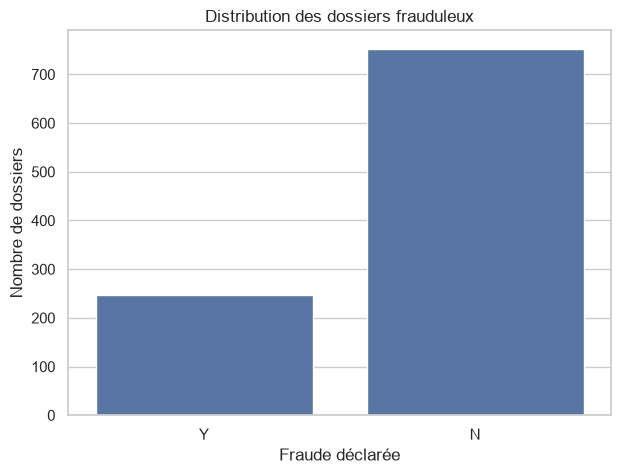

In [27]:
plt.figure(figsize=(7, 5))

sns.countplot(
    data=df_ins_claims,
    x=target
)

plt.title("Distribution des dossiers frauduleux")
plt.xlabel("Fraude déclarée")
plt.ylabel("Nombre de dossiers")
plt.show()

In [28]:
fraud_severity = (
    df_ins_claims
    .assign(
        fraud=df_ins_claims["fraud_reported"].eq("Y").astype(int)
    )
    .groupby("incident_severity")["fraud"]
    .agg(["count", "mean"])
)

fraud_severity["fraud_rate_%"] = (
    fraud_severity["mean"] * 100
)

fraud_severity.sort_values(
    "fraud_rate_%",
    ascending=False
)

,count,mean,fraud_rate_%
incident_severity,,,
Major Damage,276,0.605072,60.507246
Total Loss,280,0.128571,12.857143
Minor Damage,354,0.107345,10.734463
Trivial Damage,90,0.066667,6.666667


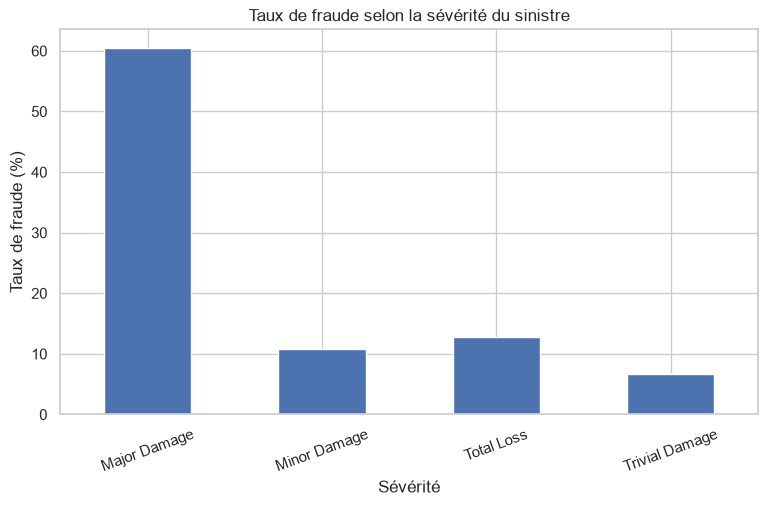

In [29]:
fraud_severity["fraud_rate_%"].plot(
    kind="bar",
    figsize=(9, 5)
)

plt.title("Taux de fraude selon la sévérité du sinistre")
plt.xlabel("Sévérité")
plt.ylabel("Taux de fraude (%)")
plt.xticks(rotation=20)

plt.show()

In [30]:
fraud_severity = (
    df_ins_claims
    .assign(
        fraud=df_ins_claims["fraud_reported"].eq("Y").astype(int)
    )
    .groupby("incident_severity")["fraud"]
    .agg(["count", "mean"])
)

fraud_severity["fraud_rate_%"] = (
    fraud_severity["mean"] * 100
)

fraud_severity.sort_values(
    "fraud_rate_%",
    ascending=False
)

,count,mean,fraud_rate_%
incident_severity,,,
Major Damage,276,0.605072,60.507246
Total Loss,280,0.128571,12.857143
Minor Damage,354,0.107345,10.734463
Trivial Damage,90,0.066667,6.666667


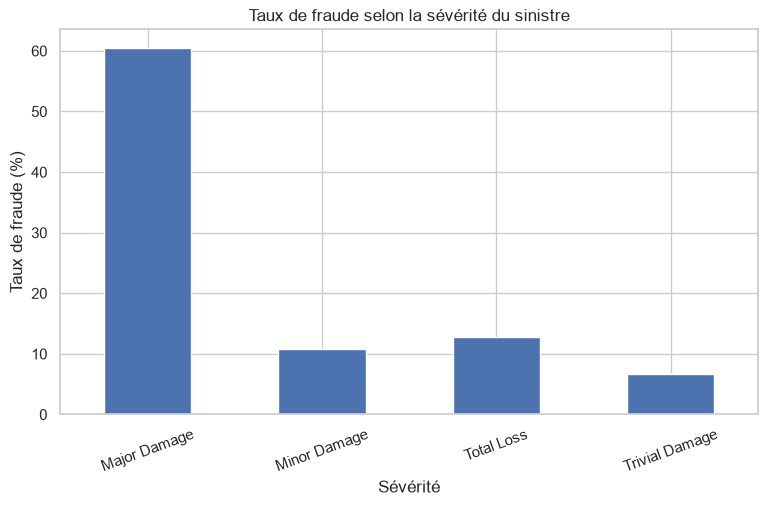

In [31]:
fraud_severity["fraud_rate_%"].plot(
    kind="bar",
    figsize=(9, 5)
)

plt.title("Taux de fraude selon la sévérité du sinistre")
plt.xlabel("Sévérité")
plt.ylabel("Taux de fraude (%)")
plt.xticks(rotation=20)

plt.show()

In [32]:
fraud_type = (
    df_ins_claims
    .assign(
        fraud=df_ins_claims["fraud_reported"].eq("Y").astype(int)
    )
    .groupby("incident_type")["fraud"]
    .agg(["count", "mean"])
)

fraud_type["fraud_rate_%"] = (
    fraud_type["mean"] * 100
)

fraud_type.sort_values(
    "fraud_rate_%",
    ascending=False
)

,count,mean,fraud_rate_%
incident_type,,,
Single Vehicle Collision,403,0.290323,29.032258
Multi-vehicle Collision,419,0.272076,27.207637
Parked Car,84,0.095238,9.523810
Vehicle Theft,94,0.085106,8.510638


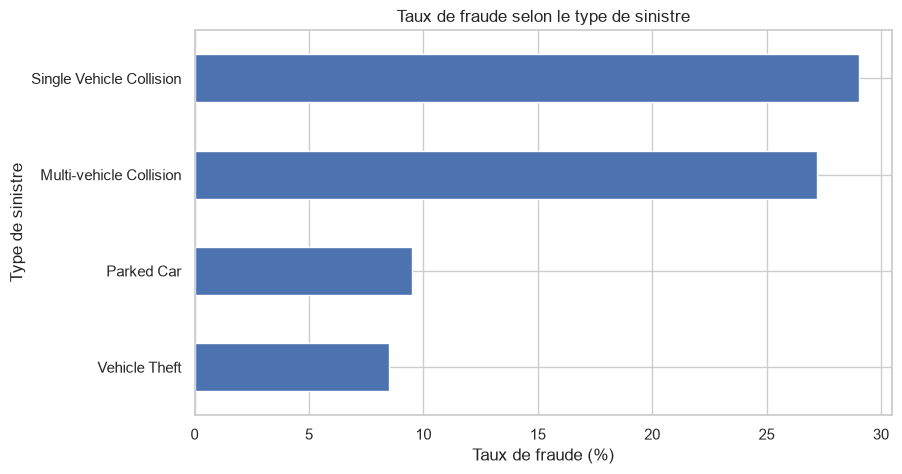

In [33]:
plt.figure(figsize=(9, 5))

fraud_type["fraud_rate_%"].sort_values().plot(
    kind="barh"
)

plt.title("Taux de fraude selon le type de sinistre")
plt.xlabel("Taux de fraude (%)")
plt.ylabel("Type de sinistre")

plt.show()

In [34]:
fraud_collision = (
    df_ins_claims
    .assign(
        fraud=df_ins_claims["fraud_reported"].eq("Y").astype(int)
    )
    .groupby("collision_type")["fraud"]
    .agg(["count", "mean"])
)

fraud_collision["fraud_rate_%"] = (
    fraud_collision["mean"] * 100
)

fraud_collision.sort_values(
    "fraud_rate_%",
    ascending=False
)

,count,mean,fraud_rate_%
collision_type,,,
Rear Collision,292,0.311644,31.164384
Front Collision,254,0.275591,27.559055
Side Collision,276,0.253623,25.362319


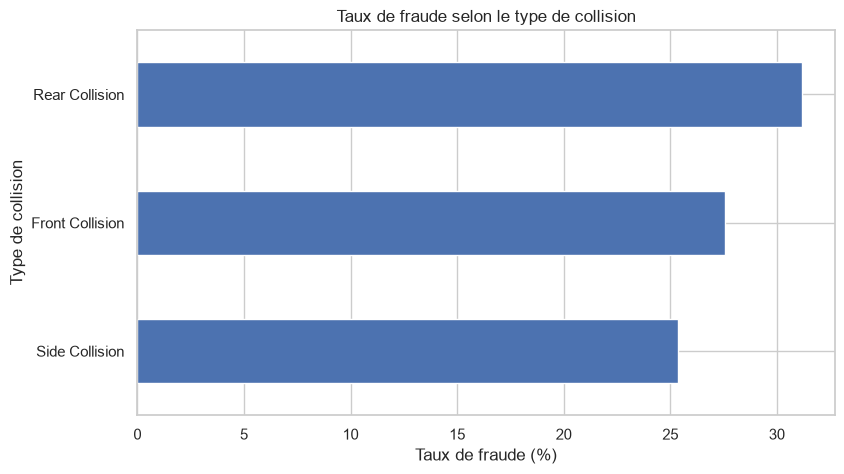

In [35]:
plt.figure(figsize=(9, 5))

fraud_collision["fraud_rate_%"].sort_values().plot(
    kind="barh"
)

plt.title("Taux de fraude selon le type de collision")
plt.xlabel("Taux de fraude (%)")
plt.ylabel("Type de collision")

plt.show()

In [36]:
# =========================
# Analyse des montants des sinistres
# =========================

claim_columns = [
    "total_claim_amount",
    "injury_claim",
    "property_claim",
    "vehicle_claim"
]

df_ins_claims.groupby("fraud_reported")[claim_columns].agg(
    ["mean", "median", "std"]
).round(2)

total_claim_amount                    injury_claim          \
                             mean   median       std         mean  median   
fraud_reported                                                              
N                        50288.61  56520.0  27575.19      7179.23  6620.0   
Y                        60302.11  61290.0  20746.28      8208.34  7240.0   

                        property_claim                  vehicle_claim  \
                    std           mean  median      std          mean   
fraud_reported                                                          
N               4961.20        7018.88  6560.0  4828.92      36090.49   
Y               4550.31        8560.12  7440.0  4631.74      43533.64   

                                   
                 median       std  
fraud_reported                     
N               41220.0  19698.05  
Y               44800.0  14849.39

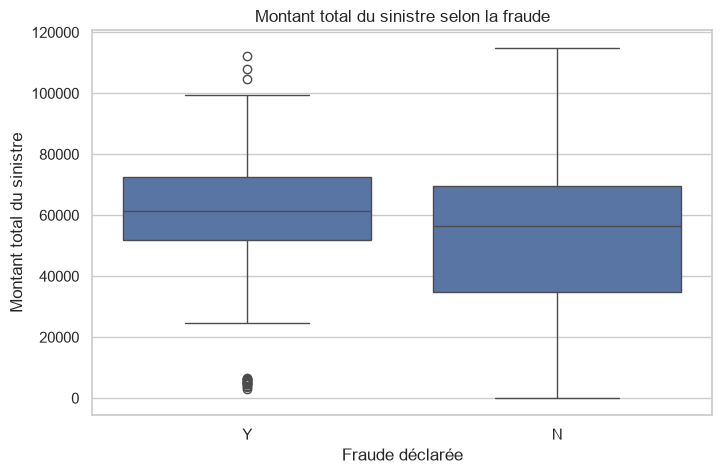

In [37]:
plt.figure(figsize=(8, 5))

sns.boxplot(
    data=df_ins_claims,
    x="fraud_reported",
    y="total_claim_amount"
)

plt.title("Montant total du sinistre selon la fraude")
plt.xlabel("Fraude déclarée")
plt.ylabel("Montant total du sinistre")

plt.show()

In [38]:
# analyser le nombre de véhicules impliqués
pd.crosstab(
    df_ins_claims["number_of_vehicles_involved"],
    df_ins_claims["fraud_reported"],
    normalize="index"
).mul(100).round(2)

fraud_reported,N,Y
number_of_vehicles_involved,,
1,77.11,22.89
2,70.00,30.00
3,73.74,26.26
4,64.52,35.48


In [39]:
# analyser les témoins
pd.crosstab(
    df_ins_claims["witnesses"],
    df_ins_claims["fraud_reported"],
    normalize="index"
).mul(100).round(2)

fraud_reported,N,Y
witnesses,,
0,79.92,20.08
1,75.58,24.42
2,70.40,29.60
3,75.31,24.69


In [40]:
# analyser les blessures corporelles
pd.crosstab(
    df_ins_claims["bodily_injuries"],
    df_ins_claims["fraud_reported"],
    normalize="index"
).mul(100).round(2)

fraud_reported,N,Y
bodily_injuries,,
0,76.47,23.53
1,76.52,23.48
2,72.89,27.11


In [41]:
# Vérification des variables à forte cardinalité

print("Nombre de policy_number uniques :", df_ins_claims["policy_number"].nunique())
print("Nombre de incident_location uniques :", df_ins_claims["incident_location"].nunique())
print("Nombre de insured_zip uniques :", df_ins_claims["insured_zip"].nunique())

Nombre de policy_number uniques : 1000
Nombre de incident_location uniques : 1000
Nombre de insured_zip uniques : 995


In [42]:
# Vérification de umbrella_limit

df_ins_claims["umbrella_limit"].describe()

count    1.000000e+03
mean     1.101000e+06
std      2.297407e+06
min     -1.000000e+06
25%      0.000000e+00
50%      0.000000e+00
75%      0.000000e+00
max      1.000000e+07
Name: umbrella_limit, dtype: float64

In [43]:
df_ins_claims["umbrella_limit"].value_counts().sort_index()

umbrella_limit
-1000000       1
 0           798
 2000000       3
 3000000      12
 4000000      39
 5000000      46
 6000000      57
 7000000      29
 8000000       8
 9000000       5
 10000000      2
Name: count, dtype: int64

In [44]:
df_ins_claims[
    df_ins_claims["umbrella_limit"] < 0
][
    ["umbrella_limit", "fraud_reported"]
]

,umbrella_limit,fraud_reported
290,-1000000,N


🎯 Feature Engineering

In [45]:
# =========================
# Feature Engineering
# =========================

# Conversion des dates

df_ins_claims["policy_bind_date"] = pd.to_datetime(
    df_ins_claims["policy_bind_date"]
)

df_ins_claims["incident_date"] = pd.to_datetime(
    df_ins_claims["incident_date"]
)

In [46]:
# Variables temporelles

df_ins_claims["policy_bind_year"] = (
    df_ins_claims["policy_bind_date"].dt.year
)

df_ins_claims["policy_bind_month"] = (
    df_ins_claims["policy_bind_date"].dt.month
)

df_ins_claims["incident_year"] = (
    df_ins_claims["incident_date"].dt.year
)

df_ins_claims["incident_month"] = (
    df_ins_claims["incident_date"].dt.month
)

df_ins_claims["policy_duration_days"] = (
    df_ins_claims["incident_date"]
    - df_ins_claims["policy_bind_date"]
).dt.days

In [47]:
df_ins_claims[
    [
        "policy_bind_date",
        "incident_date",
        "policy_bind_year",
        "policy_bind_month",
        "incident_year",
        "incident_month",
        "policy_duration_days"
    ]
].head()

,policy_bind_date,incident_date,policy_bind_year,policy_bind_month,incident_year,incident_month,policy_duration_days
0,2014-10-17,2015-01-25,2014,10,2015,1,100
1,2006-06-27,2015-01-21,2006,6,2015,1,3130
2,2000-09-06,2015-02-22,2000,9,2015,2,5282
3,1990-05-25,2015-01-10,1990,5,2015,1,8996
4,2014-06-06,2015-02-17,2014,6,2015,2,256


In [48]:
# Âge du véhicule au moment du sinistre

df_ins_claims["vehicle_age"] = (
    df_ins_claims["incident_date"].dt.year
    - df_ins_claims["auto_year"]
)

df_ins_claims[
    ["auto_year", "incident_date", "vehicle_age"]
].head()

,auto_year,incident_date,vehicle_age
0,2004,2015-01-25,11
1,2007,2015-01-21,8
2,2007,2015-02-22,8
3,2014,2015-01-10,1
4,2009,2015-02-17,6


In [49]:
df_ins_claims["vehicle_age"].describe()

count    1000.000000
mean        9.897000
std         6.015861
min         0.000000
25%         5.000000
50%        10.000000
75%        15.000000
max        20.000000
Name: vehicle_age, dtype: float64

In [50]:
def get_time_period(hour):
    if 6 <= hour < 12:
        return "Morning"
    elif 12 <= hour < 18:
        return "Afternoon"
    elif 18 <= hour < 24:
        return "Evening"
    else:
        return "Night"


df_ins_claims["incident_period"] = (
    df_ins_claims["incident_hour_of_the_day"]
    .apply(get_time_period)
)

In [51]:
df_ins_claims["incident_period"].value_counts()

incident_period
Afternoon    271
Evening      246
Night        244
Morning      239
Name: count, dtype: int64

🎯 Sélection des variables

In [52]:
# Liste des variables disponibles après Feature Engineering

df_ins_claims.columns.tolist()

['months_as_customer',
 'age',
 'policy_number',
 'policy_bind_date',
 'policy_state',
 'policy_csl',
 'policy_deductable',
 'policy_annual_premium',
 'umbrella_limit',
 'insured_zip',
 'insured_sex',
 'insured_education_level',
 'insured_occupation',
 'insured_hobbies',
 'insured_relationship',
 'capital-gains',
 'capital-loss',
 'incident_date',
 'incident_type',
 'collision_type',
 'incident_severity',
 'authorities_contacted',
 'incident_state',
 'incident_city',
 'incident_location',
 'incident_hour_of_the_day',
 'number_of_vehicles_involved',
 'property_damage',
 'bodily_injuries',
 'witnesses',
 'police_report_available',
 'total_claim_amount',
 'injury_claim',
 'property_claim',
 'vehicle_claim',
 'auto_make',
 'auto_model',
 'auto_year',
 'fraud_reported',
 'policy_bind_year',
 'policy_bind_month',
 'incident_year',
 'incident_month',
 'policy_duration_days',
 'vehicle_age',
 'incident_period']

In [53]:
print("Nombre de variables :", df_ins_claims.shape[1])
print("Nombre de lignes :", df_ins_claims.shape[0])

Nombre de variables : 46
Nombre de lignes : 1000


In [54]:
# Valeurs manquantes restantes

missing = df_ins_claims.isnull().sum()
missing = missing[missing > 0].sort_values(ascending=False)

missing

property_damage            360
police_report_available    343
collision_type             178
dtype: int64

In [55]:
# Vérification des doublons

print("Nombre de doublons :", df_ins_claims.duplicated().sum())

Nombre de doublons : 0


🎯 Préparer les données pour le Machine Learning

In [56]:
# =========================
# Préparation des données ML
# =========================

df_ml = df_ins_claims.copy()

In [57]:
columns_to_drop = [
    "policy_number",
    "incident_location",
    "insured_zip",
    "policy_bind_date",
    "incident_date",
    "_c39"
]

df_ml = df_ml.drop(
    columns=columns_to_drop,
    errors="ignore"
)

In [58]:
claim_amount_columns = [
    "total_claim_amount",
    "injury_claim",
    "property_claim",
    "vehicle_claim"
]

df_ml = df_ml.drop(
    columns=claim_amount_columns,
    errors="ignore"
)

In [59]:
print("Dimensions finales :", df_ml.shape)

df_ml.head()

Dimensions finales : (1000, 37)


,months_as_customer,age,policy_state,policy_csl,policy_deductable,policy_annual_premium,umbrella_limit,insured_sex,insured_education_level,insured_occupation,insured_hobbies,insured_relationship,capital-gains,capital-loss,incident_type,collision_type,incident_severity,authorities_contacted,incident_state,incident_city,incident_hour_of_the_day,number_of_vehicles_involved,property_damage,bodily_injuries,witnesses,police_report_available,auto_make,auto_model,auto_year,fraud_reported,policy_bind_year,policy_bind_month,incident_year,incident_month,policy_duration_days,vehicle_age,incident_period
0,328,48,OH,250/500,1000,1406.91,0,MALE,MD,craft-repair,sleeping,husband,53300,0,Single Vehicle Collision,Side Collision,Major Damage,Police,SC,Columbus,5,1,YES,1,2,YES,Saab,92x,2004,Y,2014,10,2015,1,100,11,Night
1,228,42,IN,250/500,2000,1197.22,5000000,MALE,MD,machine-op-inspct,reading,other-relative,0,0,Vehicle Theft,NaN,Minor Damage,Police,VA,Riverwood,8,1,NaN,0,0,NaN,Mercedes,E400,2007,Y,2006,6,2015,1,3130,8,Morning
2,134,29,OH,100/300,2000,1413.14,5000000,FEMALE,PhD,sales,board-games,own-child,35100,0,Multi-vehicle Collision,Rear Collision,Minor Damage,Police,NY,Columbus,7,3,NO,2,3,NO,Dodge,RAM,2007,N,2000,9,2015,2,5282,8,Morning
3,256,41,IL,250/500,2000,1415.74,6000000,FEMALE,PhD,armed-forces,board-games,unmarried,48900,-62400,Single Vehicle Collision,Front Collision,Major Damage,Police,OH,Arlington,5,1,NaN,1,2,NO,Chevrolet,Tahoe,2014,Y,1990,5,2015,1,8996,1,Night
4,228,44,IL,500/1000,1000,1583.91,6000000,MALE,Associate,sales,board-games,unmarried,66000,-46000,Vehicle Theft,NaN,Minor Damage,Unknown,NY,Arlington,20,1,NO,0,1,NO,Accura,RSX,2009,N,2014,6,2015,2,256,6,Evening


In [60]:
df_ml.dtypes

months_as_customer               int64
age                              int64
policy_state                       str
policy_csl                         str
policy_deductable                int64
policy_annual_premium          float64
umbrella_limit                   int64
insured_sex                        str
insured_education_level            str
insured_occupation                 str
insured_hobbies                    str
insured_relationship               str
capital-gains                    int64
capital-loss                     int64
incident_type                      str
collision_type                     str
incident_severity                  str
authorities_contacted              str
incident_state                     str
incident_city                      str
incident_hour_of_the_day         int64
number_of_vehicles_involved      int64
property_damage                    str
bodily_injuries                  int64
witnesses                        int64
police_report_available  

In [61]:
# Variable cible

X = df_ml.drop(columns=["fraud_reported"])

y = df_ml["fraud_reported"].map({
    "N": 0,
    "Y": 1
})

In [62]:
print("Dimensions de X :", X.shape)
print("Dimensions de y :", y.shape)

print("\nDistribution de la cible :")
print(y.value_counts())

print("\nDistribution en pourcentage :")
print(
    y.value_counts(normalize=True)
    .mul(100)
    .round(2)
)

Dimensions de X : (1000, 36)
Dimensions de y : (1000,)

Distribution de la cible :
fraud_reported
0    753
1    247
Name: count, dtype: int64

Distribution en pourcentage :
fraud_reported
0    75.3
1    24.7
Name: proportion, dtype: float64


In [63]:
numeric_features = X.select_dtypes(
    include=["int64", "float64"]
).columns.tolist()

categorical_features = X.select_dtypes(
    include=["object"]
).columns.tolist()

print("Variables numériques :", len(numeric_features))
print(numeric_features)

print("\nVariables catégorielles :", len(categorical_features))
print(categorical_features)

Variables numériques : 14
['months_as_customer', 'age', 'policy_deductable', 'policy_annual_premium', 'umbrella_limit', 'capital-gains', 'capital-loss', 'incident_hour_of_the_day', 'number_of_vehicles_involved', 'bodily_injuries', 'witnesses', 'auto_year', 'policy_duration_days', 'vehicle_age']

Variables catégorielles : 18
['policy_state', 'policy_csl', 'insured_sex', 'insured_education_level', 'insured_occupation', 'insured_hobbies', 'insured_relationship', 'incident_type', 'collision_type', 'incident_severity', 'authorities_contacted', 'incident_state', 'incident_city', 'property_damage', 'police_report_available', 'auto_make', 'auto_model', 'incident_period']


C:\Users\pc\AppData\Local\Temp\ipykernel_8428\306299148.py:5: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_features = X.select_dtypes(


🎯 Train / Test Split

In [64]:
from sklearn.model_selection import train_test_split

In [65]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

In [66]:
print("X_train :", X_train.shape)
print("X_test  :", X_test.shape)
print("y_train :", y_train.shape)
print("y_test  :", y_test.shape)

X_train : (800, 36)
X_test  : (200, 36)
y_train : (800,)
y_test  : (200,)


In [67]:
print("Train :")
print(y_train.value_counts(normalize=True).mul(100).round(2))

print("\nTest :")
print(y_test.value_counts(normalize=True).mul(100).round(2))

Train :
fraud_reported
0    75.25
1    24.75
Name: proportion, dtype: float64

Test :
fraud_reported
0    75.5
1    24.5
Name: proportion, dtype: float64


🎯 Preprocessing

In [68]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

In [69]:
numeric_features = X_train.select_dtypes(
    include=["int64", "float64"]
).columns.tolist()

categorical_features = X_train.select_dtypes(
    include=["object"]
).columns.tolist()

print("Variables numériques :", numeric_features)
print("\nVariables catégorielles :", categorical_features)

Variables numériques : ['months_as_customer', 'age', 'policy_deductable', 'policy_annual_premium', 'umbrella_limit', 'capital-gains', 'capital-loss', 'incident_hour_of_the_day', 'number_of_vehicles_involved', 'bodily_injuries', 'witnesses', 'auto_year', 'policy_duration_days', 'vehicle_age']

Variables catégorielles : ['policy_state', 'policy_csl', 'insured_sex', 'insured_education_level', 'insured_occupation', 'insured_hobbies', 'insured_relationship', 'incident_type', 'collision_type', 'incident_severity', 'authorities_contacted', 'incident_state', 'incident_city', 'property_damage', 'police_report_available', 'auto_make', 'auto_model', 'incident_period']


C:\Users\pc\AppData\Local\Temp\ipykernel_8428\2728993401.py:5: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_features = X_train.select_dtypes(


In [70]:
numeric_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(
        handle_unknown="ignore",
        sparse_output=False
    ))
])

In [71]:
preprocessor = ColumnTransformer([
    ("num", numeric_pipeline, numeric_features),
    ("cat", categorical_pipeline, categorical_features)
])

🎯 Premier modèle : Logistic Regression

In [72]:
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline

from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_auc_score,
    average_precision_score
)

In [73]:
logistic_model = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", LogisticRegression(
        max_iter=1000,
        class_weight="balanced",
        random_state=42
    ))
])

In [74]:
logistic_model.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](36,)","['months_as_customer','age','policy_state',...,'policy_duration_days', 'vehicle_age','incident_period']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,36
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specify

In [75]:
y_pred = logistic_model.predict(X_test)
y_proba = logistic_model.predict_proba(X_test)[:, 1]

In [76]:
print(classification_report(
    y_test,
    y_pred,
    target_names=["Non fraude", "Fraude"]
))

              precision    recall  f1-score   support

  Non fraude       0.89      0.85      0.87       151
      Fraude       0.60      0.67      0.63        49

    accuracy                           0.81       200
   macro avg       0.74      0.76      0.75       200
weighted avg       0.82      0.81      0.81       200



In [77]:
roc_auc = roc_auc_score(y_test, y_proba)
pr_auc = average_precision_score(y_test, y_proba)

print(f"ROC-AUC : {roc_auc:.4f}")
print(f"PR-AUC  : {pr_auc:.4f}")

ROC-AUC : 0.8309
PR-AUC  : 0.5260


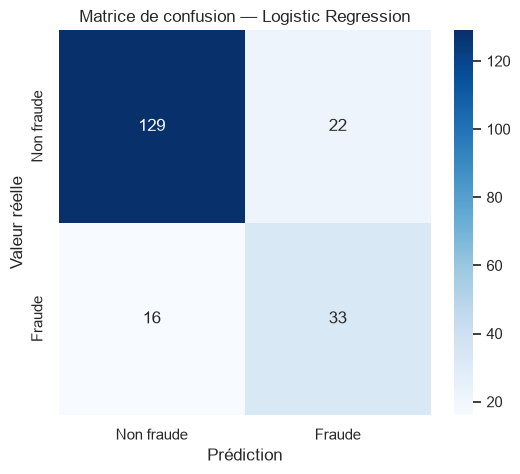

In [78]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Non fraude", "Fraude"],
    yticklabels=["Non fraude", "Fraude"]
)

plt.title("Matrice de confusion — Logistic Regression")
plt.xlabel("Prédiction")
plt.ylabel("Valeur réelle")

plt.show()

🎯 Mon avis

C'est un bon premier résultat. Je ne chercherais pas à modifier immédiatement ton preprocessing.

Le point le plus important est la classe Fraude :

Recall = 67 % → le modèle détecte environ 2 fraudes sur 3.
Precision = 60 % → parmi les dossiers signalés comme frauduleux, environ 60 % sont réellement frauduleux.
F1 = 63 % → performance correcte pour un modèle de référence.

L'accuracy de 81 % n'est pas le chiffre principal à mettre en avant, car notre problème concerne la détection de fraude.

🎯 Deuxième modèle : Random Forest 🌲

In [79]:
from sklearn.ensemble import RandomForestClassifier

In [80]:
random_forest_model = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", RandomForestClassifier(
        n_estimators=300,
        max_depth=None,
        min_samples_split=2,
        min_samples_leaf=1,
        class_weight="balanced",
        random_state=42,
        n_jobs=-1
    ))
])

In [81]:
random_forest_model.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](36,)","['months_as_customer','age','policy_state',...,'policy_duration_days', 'vehicle_age','incident_period']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,36
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specify

In [82]:
y_pred_rf = random_forest_model.predict(X_test)
y_proba_rf = random_forest_model.predict_proba(X_test)[:, 1]

In [83]:
print(classification_report(
    y_test,
    y_pred_rf,
    target_names=["Non fraude", "Fraude"]
))

              precision    recall  f1-score   support

  Non fraude       0.92      0.87      0.89       151
      Fraude       0.66      0.78      0.71        49

    accuracy                           0.84       200
   macro avg       0.79      0.82      0.80       200
weighted avg       0.86      0.84      0.85       200



In [84]:
roc_auc_rf = roc_auc_score(y_test, y_proba_rf)
pr_auc_rf = average_precision_score(y_test, y_proba_rf)

print(f"ROC-AUC : {roc_auc_rf:.4f}")
print(f"PR-AUC  : {pr_auc_rf:.4f}")

ROC-AUC : 0.8268
PR-AUC  : 0.5260


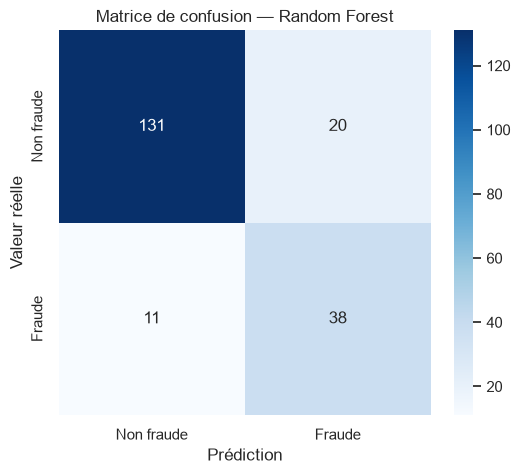

In [85]:
cm_rf = confusion_matrix(y_test, y_pred_rf)

plt.figure(figsize=(6, 5))

sns.heatmap(
    cm_rf,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Non fraude", "Fraude"],
    yticklabels=["Non fraude", "Fraude"]
)

plt.title("Matrice de confusion — Random Forest")
plt.xlabel("Prédiction")
plt.ylabel("Valeur réelle")

plt.show()

🚀 Solution : optimisation de RF

In [86]:
from sklearn.model_selection import RandomizedSearchCV

In [87]:
rf_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", RandomForestClassifier(
        class_weight="balanced",
        random_state=42,
        n_jobs=-1
    ))
])

In [88]:
param_grid_rf = {
    "classifier__n_estimators": [300, 500, 700],
    "classifier__max_depth": [5, 8, 12, 16, None],
    "classifier__min_samples_split": [2, 5, 10],
    "classifier__min_samples_leaf": [1, 2, 4, 8],
    "classifier__max_features": ["sqrt", "log2", None]
}

In [89]:
random_search_rf = RandomizedSearchCV(
    estimator=rf_pipeline,
    param_distributions=param_grid_rf,
    n_iter=30,
    scoring="f1",
    cv=5,
    random_state=42,
    n_jobs=-1,
    verbose=1
)

In [90]:
random_search_rf.fit(X_train, y_train)

Fitting 5 folds for each of 30 candidates, totalling 150 fits


,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...m_state=42))])
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'classifier__max_depth': [5, 8, ...], 'classifier__max_features': ['sqrt', 'log2', ...], 'classifier__min_samples_leaf': [1, 2, ...], 'classifier__min_samples_split': [2, 5, ...], ...}"
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",30
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",'f1'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: int, default = 0Controls the verbosity of information printed during fitting, with highervalues yielding more detailed logging.- 0 : no messages are printed;- >=1 : summary of the total number of fits;- >=2 : computation time for each fold and parameter candidate;- >=3 : fold indices and scores;- >=10 : parameter candidate indices and START messages before each fit.",1
,"random_state random_state: int, RandomState instance or None, default=NonePseudo random number generator state used for random uniform samplingfrom lists of possible values instead of scipy.stats distributions.Pass an int for reproducible output across multiplefunction calls.See :term:`Glossary <random_state>`.",42
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estim

In [91]:
print("Meilleurs paramètres :")
print(random_search_rf.best_params_)

print("\nMeilleur score CV :")
print(random_search_rf.best_score_)

Meilleurs paramètres :
{'classifier__n_estimators': 700, 'classifier__min_samples_split': 2, 'classifier__min_samples_leaf': 8, 'classifier__max_features': None, 'classifier__max_depth': 5}

Meilleur score CV :
0.7557454367810987


In [92]:
best_rf = random_search_rf.best_estimator_

In [93]:
y_pred_best_rf = best_rf.predict(X_test)

y_proba_best_rf = best_rf.predict_proba(X_test)[:, 1]

In [94]:
print(classification_report(
    y_test,
    y_pred_best_rf,
    target_names=["Non fraude", "Fraude"]
))

              precision    recall  f1-score   support

  Non fraude       0.95      0.84      0.89       151
      Fraude       0.64      0.86      0.73        49

    accuracy                           0.84       200
   macro avg       0.79      0.85      0.81       200
weighted avg       0.87      0.84      0.85       200



In [95]:
roc_auc_best_rf = roc_auc_score(
    y_test,
    y_proba_best_rf
)

pr_auc_best_rf = average_precision_score(
    y_test,
    y_proba_best_rf
)

print(f"ROC-AUC : {roc_auc_best_rf:.4f}")
print(f"PR-AUC  : {pr_auc_best_rf:.4f}")

ROC-AUC : 0.8366
PR-AUC  : 0.6265


In [96]:
from sklearn.metrics import f1_score
import numpy as np

thresholds = np.arange(0.10, 0.91, 0.01)

f1_scores = []

for threshold in thresholds:
    predictions = (
        y_proba_best_rf >= threshold
    ).astype(int)

    f1_scores.append(
        f1_score(y_test, predictions)
    )

best_threshold = thresholds[
    np.argmax(f1_scores)
]

best_f1 = max(f1_scores)

print("Meilleur seuil :", round(best_threshold, 2))
print("Meilleur F1 :", round(best_f1, 4))

Meilleur seuil : 0.2
Meilleur F1 : 0.7304


In [97]:
y_pred_threshold = (
    y_proba_best_rf >= best_threshold
).astype(int)

print(classification_report(
    y_test,
    y_pred_threshold,
    target_names=["Non fraude", "Fraude"]
))

              precision    recall  f1-score   support

  Non fraude       0.95      0.84      0.89       151
      Fraude       0.64      0.86      0.73        49

    accuracy                           0.84       200
   macro avg       0.79      0.85      0.81       200
weighted avg       0.87      0.84      0.85       200



🎯 Troisieme modèle : XGBoost

In [98]:
from xgboost import XGBClassifier

xgb_model = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", XGBClassifier(
        n_estimators=300,
        max_depth=5,
        learning_rate=0.05,
        subsample=0.8,
        colsample_bytree=0.8,
        objective="binary:logistic",
        eval_metric="logloss",
        random_state=42,
        n_jobs=-1
    ))
])

In [99]:
xgb_model.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](36,)","['months_as_customer','age','policy_state',...,'policy_duration_days', 'vehicle_age','incident_period']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,36
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specify

In [100]:
y_pred_xgb = xgb_model.predict(X_test)
y_proba_xgb = xgb_model.predict_proba(X_test)[:, 1]

In [101]:
print(classification_report(
    y_test,
    y_pred_xgb,
    target_names=["Non fraude", "Fraude"]
))

              precision    recall  f1-score   support

  Non fraude       0.84      0.89      0.86       151
      Fraude       0.59      0.49      0.53        49

    accuracy                           0.79       200
   macro avg       0.71      0.69      0.70       200
weighted avg       0.78      0.79      0.78       200



In [102]:
roc_auc_xgb = roc_auc_score(
    y_test,
    y_proba_xgb
)

pr_auc_xgb = average_precision_score(
    y_test,
    y_proba_xgb
)

print(f"ROC-AUC : {roc_auc_xgb:.4f}")
print(f"PR-AUC  : {pr_auc_xgb:.4f}")

ROC-AUC : 0.8357
PR-AUC  : 0.5688


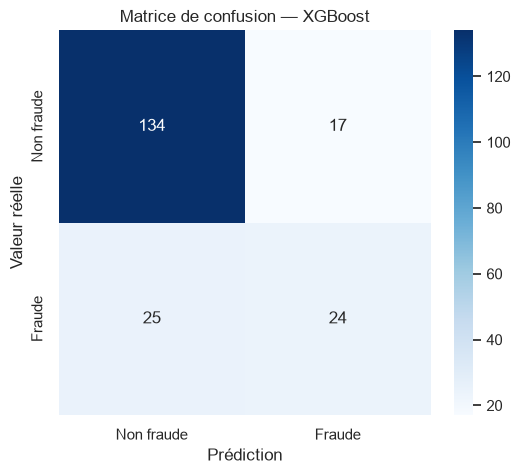

In [103]:
cm_xgb = confusion_matrix(
    y_test,
    y_pred_xgb
)

plt.figure(figsize=(6, 5))

sns.heatmap(
    cm_xgb,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Non fraude", "Fraude"],
    yticklabels=["Non fraude", "Fraude"]
)

plt.title("Matrice de confusion — XGBoost")
plt.xlabel("Prédiction")
plt.ylabel("Valeur réelle")

plt.show()

In [106]:
from sklearn.metrics import (
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    classification_report,
    confusion_matrix
)

In [107]:
comparison_final = pd.DataFrame({
    "Modèle": [
        "Logistic Regression",
        "Random Forest",
        "Random Forest optimisé",
        "XGBoost"
    ],
    "Precision_Fraude": [
        precision_score(y_test, y_pred),
        precision_score(y_test, y_pred_rf),
        precision_score(y_test, y_pred_best_rf),
        precision_score(y_test, y_pred_xgb)
    ],
    "Recall_Fraude": [
        recall_score(y_test, y_pred),
        recall_score(y_test, y_pred_rf),
        recall_score(y_test, y_pred_best_rf),
        recall_score(y_test, y_pred_xgb)
    ],
    "F1_Fraude": [
        f1_score(y_test, y_pred),
        f1_score(y_test, y_pred_rf),
        f1_score(y_test, y_pred_best_rf),
        f1_score(y_test, y_pred_xgb)
    ],
    "ROC-AUC": [
        roc_auc,
        roc_auc_rf,
        roc_auc_best_rf,
        roc_auc_xgb
    ],
    "PR-AUC": [
        pr_auc,
        pr_auc_rf,
        pr_auc_best_rf,
        pr_auc_xgb
    ]
})

comparison_final.sort_values(
    "PR-AUC",
    ascending=False
).round(4)

,Modèle,Precision_Fraude,Recall_Fraude,F1_Fraude,ROC-AUC,PR-AUC
2,Random Forest optimisé,0.6364,0.8571,0.7304,0.8366,0.6265
3,XGBoost,0.5854,0.4898,0.5333,0.8357,0.5688
1,Random Forest,0.6552,0.7755,0.7103,0.8268,0.5260
0,Logistic Regression,0.6000,0.6735,0.6346,0.8309,0.5260


🧠 Explainable AI avec SHAP

In [108]:
# =========================
# Sélection du meilleur modèle
# =========================

comparison_final.sort_values(
    "PR-AUC",
    ascending=False
).round(4)

,Modèle,Precision_Fraude,Recall_Fraude,F1_Fraude,ROC-AUC,PR-AUC
2,Random Forest optimisé,0.6364,0.8571,0.7304,0.8366,0.6265
3,XGBoost,0.5854,0.4898,0.5333,0.8357,0.5688
1,Random Forest,0.6552,0.7755,0.7103,0.8268,0.5260
0,Logistic Regression,0.6000,0.6735,0.6346,0.8309,0.5260


In [109]:
print("Meilleur seuil Random Forest :", round(best_threshold, 2))
print("F1 obtenu :", round(best_f1, 4))

Meilleur seuil Random Forest : 0.2
F1 obtenu : 0.7304


In [112]:
import shap

print("Version SHAP :", shap.__version__)

Version SHAP : 0.52.0


In [113]:
# Récupérer le préprocesseur et le modèle Random Forest

rf_preprocessor = best_rf.named_steps["preprocessor"]
rf_classifier = best_rf.named_steps["classifier"]

In [114]:
X_train_transformed = rf_preprocessor.transform(X_train)
X_test_transformed = rf_preprocessor.transform(X_test)

print("X_train transformé :", X_train_transformed.shape)
print("X_test transformé :", X_test_transformed.shape)

X_train transformé : (800, 160)
X_test transformé : (200, 160)


In [115]:
feature_names = rf_preprocessor.get_feature_names_out()

print("Nombre de variables après encodage :", len(feature_names))

print(feature_names[:20])

Nombre de variables après encodage : 160
['num__months_as_customer' 'num__age' 'num__policy_deductable'
 'num__policy_annual_premium' 'num__umbrella_limit' 'num__capital-gains'
 'num__capital-loss' 'num__incident_hour_of_the_day'
 'num__number_of_vehicles_involved' 'num__bodily_injuries'
 'num__witnesses' 'num__auto_year' 'num__policy_duration_days'
 'num__vehicle_age' 'cat__policy_state_IL' 'cat__policy_state_IN'
 'cat__policy_state_OH' 'cat__policy_csl_100/300'
 'cat__policy_csl_250/500' 'cat__policy_csl_500/1000']


In [116]:
explainer = shap.TreeExplainer(rf_classifier)

In [117]:
shap_values = explainer.shap_values(
    X_test_transformed
)

In [118]:
print(type(shap_values))

if isinstance(shap_values, list):
    print("Nombre de sorties :", len(shap_values))
    print("Shape classe 0 :", shap_values[0].shape)
    print("Shape classe 1 :", shap_values[1].shape)
else:
    print("Shape :", shap_values.shape)

<class 'numpy.ndarray'>
Shape : (200, 160, 2)


In [119]:
if isinstance(shap_values, list):
    shap_values_fraud = shap_values[1]
else:
    shap_values_fraud = shap_values[:, :, 1] if len(shap_values.shape) == 3 else shap_values

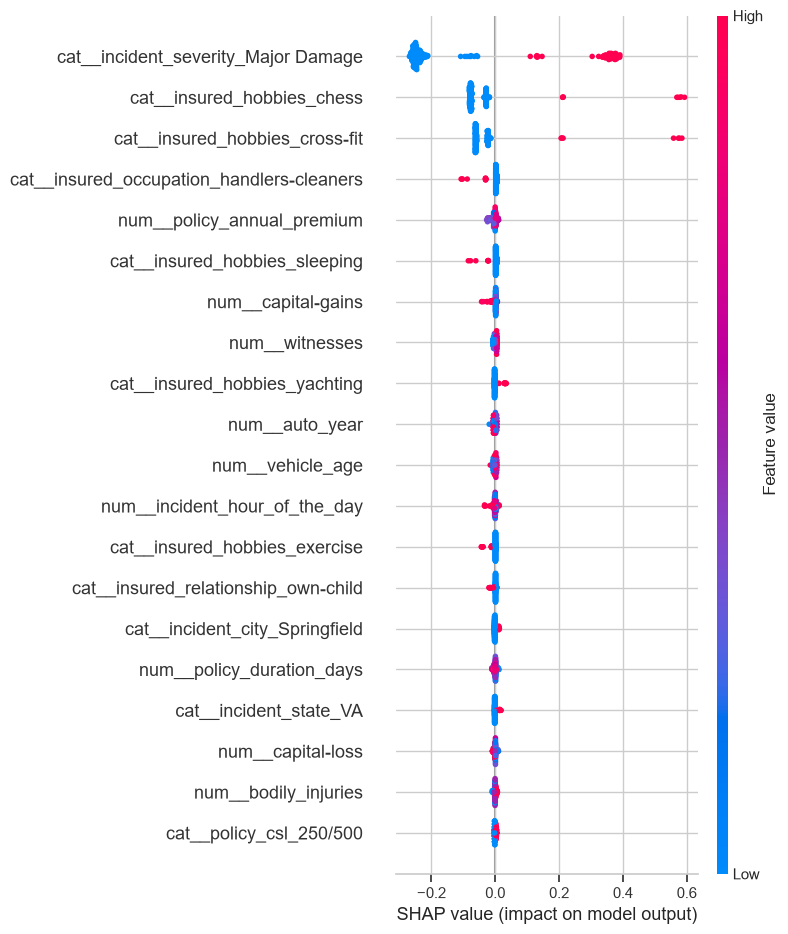

In [120]:
shap.summary_plot(
    shap_values_fraud,
    X_test_transformed,
    feature_names=feature_names,
    show=True
)

In [123]:
# =========================
# Explication d'un dossier
# =========================

# Choisir un dossier du jeu de test
sample_index = 0

sample = X_test.iloc[[sample_index]]

print("Dossier sélectionné :")
display(sample)

Dossier sélectionné :


,months_as_customer,age,policy_state,policy_csl,policy_deductable,policy_annual_premium,umbrella_limit,insured_sex,insured_education_level,insured_occupation,insured_hobbies,insured_relationship,capital-gains,capital-loss,incident_type,collision_type,incident_severity,authorities_contacted,incident_state,incident_city,incident_hour_of_the_day,number_of_vehicles_involved,property_damage,bodily_injuries,witnesses,police_report_available,auto_make,auto_model,auto_year,policy_bind_year,policy_bind_month,incident_year,incident_month,policy_duration_days,vehicle_age,incident_period
908,285,44,OH,250/500,2000,1144.3,0,MALE,MD,priv-house-serv,base-jumping,not-in-family,52600,0,Vehicle Theft,NaN,Minor Damage,Police,WV,Northbrook,3,1,YES,1,0,NaN,Honda,Civic,2010,1991,8,2015,2,8568,5,Night


In [124]:
sample_proba = best_rf.predict_proba(sample)[0, 1]

sample_prediction = int(
    sample_proba >= best_threshold
)

print(f"Probabilité de fraude : {sample_proba:.2%}")

if sample_prediction == 1:
    print("⚠️ Dossier classé comme FRAUDE")
else:
    print("✅ Dossier classé comme NON FRAUDE")

Probabilité de fraude : 9.93%
✅ Dossier classé comme NON FRAUDE


In [125]:
sample_transformed = rf_preprocessor.transform(sample)

sample_shap = explainer.shap_values(sample_transformed)

if isinstance(sample_shap, list):
    sample_shap_fraud = sample_shap[1][0]
else:
    if len(sample_shap.shape) == 3:
        sample_shap_fraud = sample_shap[0, :, 1]
    else:
        sample_shap_fraud = sample_shap[0]

In [126]:
explanation = pd.DataFrame({
    "Variable": feature_names,
    "SHAP_value": sample_shap_fraud,
    "Abs_SHAP": np.abs(sample_shap_fraud)
})

explanation = explanation.sort_values(
    "Abs_SHAP",
    ascending=False
)

explanation.head(15)

,Variable,SHAP_value,Abs_SHAP
76,cat__incident_severity_Major Damage,-0.249630,0.249630
48,cat__insured_hobbies_chess,-0.079397,0.079397
49,cat__insured_hobbies_cross-fit,-0.059342,0.059342
127,cat__auto_model_Civic,0.009681,0.009681
26,cat__insured_education_level_MD,0.007326,0.007326
13,num__vehicle_age,-0.006111,0.006111
11,num__auto_year,-0.005662,0.005662
3,num__policy_annual_premium,-0.005472,0.005472
10,num__witnesses,-0.004996,0.004996
43,cat__insured_hobbies_base-jumping,0.004053,0.004053


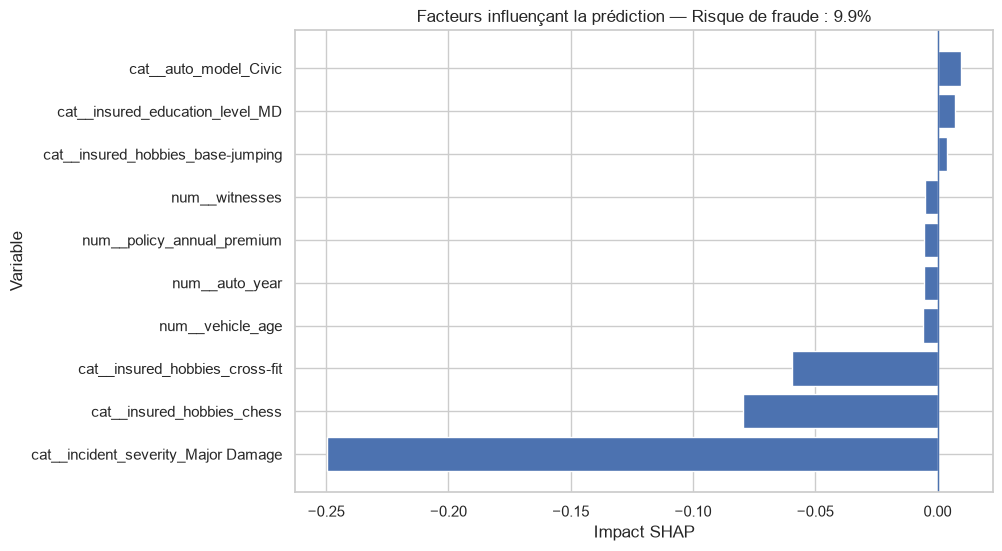

In [127]:
top_features = explanation.head(10).sort_values(
    "SHAP_value"
)

plt.figure(figsize=(9, 6))

plt.barh(
    top_features["Variable"],
    top_features["SHAP_value"]
)

plt.axvline(
    0,
    linewidth=1
)

plt.title(
    f"Facteurs influençant la prédiction — "
    f"Risque de fraude : {sample_proba:.1%}"
)

plt.xlabel("Impact SHAP")
plt.ylabel("Variable")

plt.show()

🚀 Sauvegarde du modèle final

In [128]:
import os

os.makedirs("models", exist_ok=True)

In [129]:
import joblib

# Sauvegarder le modèle
joblib.dump(
    best_rf,
    "models/fraud_detection_model.pkl"
)

['models/fraud_detection_model.pkl']

In [131]:
# Sauvegarder le seuil
joblib.dump(
    best_threshold,
    "models/fraud_threshold.pkl"
)

['models/fraud_threshold.pkl']

In [132]:
print("Modèle :", os.path.getsize(
    "models/fraud_detection_model.pkl"
), "bytes")

print("Seuil :", best_threshold)

Modèle : 1867323 bytes
Seuil : 0.19999999999999996


🧪 Teste du modèle sauvegardé

In [133]:
loaded_model = joblib.load(
    "models/fraud_detection_model.pkl"
)

loaded_threshold = joblib.load(
    "models/fraud_threshold.pkl"
)

In [134]:
test_probability = loaded_model.predict_proba(
    X_test.iloc[[0]]
)[0, 1]

test_prediction = int(
    test_probability >= loaded_threshold
)

print(f"Probabilité de fraude : {test_probability:.2%}")
print(f"Seuil : {loaded_threshold:.2f}")

if test_prediction == 1:
    print("⚠️ FRAUDE")
else:
    print("✅ NON FRAUDE")

Probabilité de fraude : 9.93%
Seuil : 0.20
✅ NON FRAUDE
